# Regressão de Ridge aplicada a canais de marketing digital

Na presente análise, vamos avaliar a relação entre Receita Líquida de vendas e a influência de diversos tipos de campanhas digitais nesse resultado.

O objetivo inicial era usar apenas a Regressão Linear simples para avaliar o impacto de cada canal. Porém, diante de uma análise preliminar, os resultados apontaram para uma forte multicolinearidade entre canais, que surgiu em decorrência de um fator externo: mudança de estratégia de campanhas durante parte do período dos dados.

Uma das primeiras alternativas a se pensar para elaborar e seguir com um modelo de maior confiabilidade costuma ser remover as variáveis independentes (preditoras) responsáveis pelo overfitting nos dados de treino.

Entretanto, para evitar abrir mão dessas variáveis, principalmente porque elas continuarão existindo (afinal, não se pode simplesmente desligar um dos canais de vendas, a menos que seja do interesse do negócio), usamos a Regressão de Ridge, que é um dos vários tipos de regularizações para modelos de regressão linear, que foca, especificamente, em reduzir erros causados por overfitting em dados de treino. Mais detalhes teóricos podem ser consultados [nessa trilha da IBM para Machine Learning](https://www.ibm.com/br-pt/think/topics/ridge-regression#1190488336).

Ao final dessa análise, há um simulador de investimento por canal que retorna a receita esperada a partir da inserção de valores de orçamentos desejados, podendo ser útil para a tomada de decisões estratégicas para operação de campanhas de marketing.


#Transformação dos dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Os dados brutos foram carregados a partir de um arquivo CSV contendo registros diários de investimento por canal e receita. Como as colunas numéricas estavam armazenadas como strings com vírgula como separador decimal (padrão brasileiro), foi necessário convertê-las para o tipo ``float`` antes de qualquer análise. A coluna de data também foi convertida para o tipo ``datetime``, permitindo ordenação cronológica correta dos registros.

In [8]:

df = pd.read_csv('dados_mistos_iniciais.csv')
df.head(3)

,Data,Pesquisa,Display,Geração de demanda,Performance Max,App,Vídeo,Produtos,Ordens,Receita Líquida,Receita Bruta
0,2026-01-01,"14640,66",0,"1877,22","1097,19","537,6",0,1404,1020,"24591,2094","161021,9394"
1,2026-01-02,"21354,33",0,"2098,53","1753,44","550,83",0,1695,1290,"32360,3559","220227,9309"
2,2026-01-03,"20438,31",0,0,"4896,87","556,8",0,1320,1041,"23411,6492","157344,3642"


In [9]:
df.dtypes

,0
Data,object
Pesquisa,object
Display,object
Geração de demanda,object
Performance Max,object
App,object
Vídeo,object
Produtos,int64
Ordens,int64
Receita Líquida,object


In [10]:
# Colunas que precisam virar float (têm vírgula como separador decimal)
colunas_float = ['Pesquisa', 'Display', 'Geração de demanda', 'Performance Max', 'App', 'Vídeo', 'Receita Líquida', 'Receita Bruta']

for col in colunas_float:
    #df[col] = df[col].astype(str).str.replace('.', '', regex=False)  # remove separador de milhar
    df[col] = df[col].str.replace(',', '.', regex=False)              # troca vírgula decimal por ponto
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)                 # converte para float

# Converter Data para tipo date
df['Data'] = pd.to_datetime(df['Data'])


# Verificar resultado
df.dtypes

,0
Data,datetime64[ns]
Pesquisa,float64
Display,float64
Geração de demanda,float64
Performance Max,float64
App,float64
Vídeo,float64
Produtos,int64
Ordens,int64
Receita Líquida,float64


In [11]:
df.head(5)

,Data,Pesquisa,Display,Geração de demanda,Performance Max,App,Vídeo,Produtos,Ordens,Receita Líquida,Receita Bruta
0,2026-01-01,14640.66,0.0,1877.22,1097.19,537.60,0.0,1404,1020,24591.2094,161021.9394
1,2026-01-02,21354.33,0.0,2098.53,1753.44,550.83,0.0,1695,1290,32360.3559,220227.9309
2,2026-01-03,20438.31,0.0,0.00,4896.87,556.80,0.0,1320,1041,23411.6492,157344.3642
3,2026-01-04,17717.88,0.0,0.00,2644.38,564.87,0.0,1242,978,21123.2121,147405.2571
4,2026-01-05,14299.44,0.0,1132.50,473.88,461.10,0.0,966,777,18867.4506,131464.8672


Tabela: Estatística descritiva

In [14]:
df[['Pesquisa', 'Display', 'Geração de demanda', 'Performance Max', 'App', 'Vídeo', 'Receita Líquida']].describe()

,Pesquisa,Display,Geração de demanda,Performance Max,App,Vídeo,Receita Líquida
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,12529.903707,320.598621,1946.420172,2400.194741,82.317414,600.494741,18266.098891
std,5900.526433,469.499252,1595.739040,3361.417042,179.852990,1142.922396,5711.509864
min,5309.670000,0.000000,0.000000,147.360000,0.000000,0.000000,8721.803700
25%,9098.895000,0.000000,1194.922500,618.135000,0.000000,0.000000,14615.480850
50%,10925.205000,85.515000,1689.915000,1114.515000,0.000000,0.000000,17200.755900
75%,13979.407500,476.362500,2526.307500,2592.922500,0.000000,530.355000,20871.498525
max,38502.120000,2987.010000,12523.200000,22814.700000,633.450000,5124.360000,36314.997900


A tabela acima resume as principais estatísticas dos dados.

Pesquisa é de longe o canal com maior investimento médio diário (12.530 reais), com desvio padrão elevado (5.901 reais), indicando variação expressiva de um dia para o outro

Performance Max aparece em segundo lugar em volume médio (2.400 reais), mas com desvio padrão ainda maior proporcionalmente (3.361 reais), o que sugere ativação irregular; alguns dias com investimento muito alto e muitos dias com valores baixos.

App e Vídeo têm mediana zero, confirmando que esses canais ficam inativos na maior parte dos dias: metade ou mais dos registros tem investimento nulo nesses canais. Display também apresenta mediana muito baixa (85 reais), reforçando uso esporádico.


A Receita Líquida média é de 18.266 reais, com desvio padrão de 5.712 reais e variação entre 8.722 e 36.315 reais; amplitude considerável que reflete tanto a sazonalidade quanto as diferentes estratégias de campanha ao longo do período.

# Análise preliminar


Quero plotar o grafico de espalhamento de todo o periodo de investimento e receita de todas as campanhas juntas.

Depois quero fazer isso apenas para as campanhas de pesquisa (para ver o efeito só dessa campanha nas vendas), depois quero das campanhas de display e de video, separadas (para ver o efeito só dessa campanha nas vendas).

Depois quero fazer isso apenas para as campanhas de PMAX (para ver o efeito só dessa campanha nas vendas).

Quero plotar o relplot para da metricas Pesquisa, receita; pesquisa, outras (exceto pmax), receita; pesquisa, outras (exceto pmax), receita.

Quero plotar a matriz de correlação pesquisa e receita; pesquisa, outras (exceto pmax), receita; pesquisa, outras, receita.

In [15]:
df.columns

Index(['Data', 'Pesquisa', 'Display', 'Geração de demanda', 'Performance Max',
       'App', 'Vídeo', 'Produtos', 'Ordens', 'Receita Líquida',
       'Receita Bruta'],
      dtype='object')

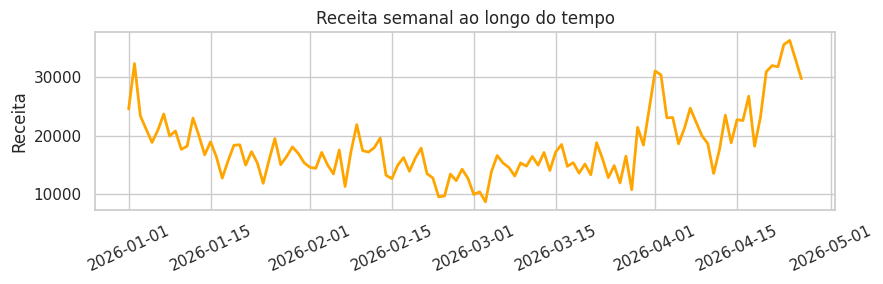

In [16]:
# configurando a estrutura do quadro
sns.set_theme(style = 'whitegrid')
fig, ax = plt.subplots(figsize = (9,3))
#fig.suptitle('Análise Exploratória - Investimento e Receita', fontsize = 14, fontweight = 'bold')

# Gráfico 1: receita ao longo do tempo
ax.plot(df['Data'], df['Receita Líquida'], color = 'orange', linewidth = 2)
ax.set_title('Receita semanal ao longo do tempo')
#ax.set_xlabel('Semana')
ax.set_ylabel('Receita')
ax.tick_params(axis = 'x', rotation = 25)

plt.tight_layout()
plt.show()

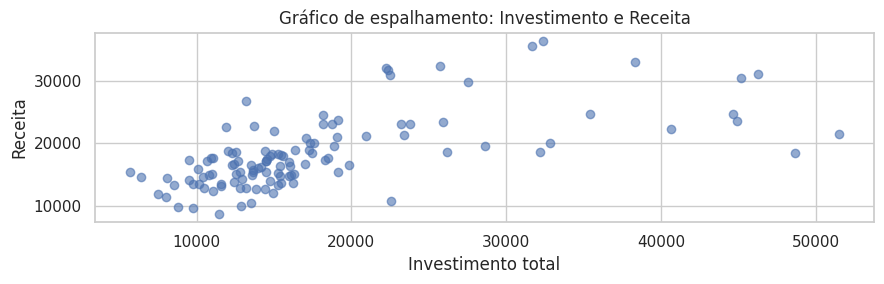

In [17]:
# Gráfico 3: correlação entre investimento TOTAL e receita
df['investimento_total'] = (df['Pesquisa'] + df['Display'] + df['Geração de demanda'] + df['App'] + df['Vídeo'] + df['Performance Max'] ) # eu vou definir essa variavel aqui pra ficar mais facil
# criando o quadro da figura e o eixo
fig, ax = plt.subplots(figsize = (9,3))


# vou plotar o espalhamento para ver graficamente se há correlação de fato entre as duas variáveis
ax.scatter(df['investimento_total'], df['Receita Líquida'], alpha = 0.6) # coloquei 0.6 só pra controlar a opacidade na sobreposição de pontos
ax.set_title('Gráfico de espalhamento: Investimento e Receita')
ax.set_xlabel('Investimento total')
ax.set_ylabel('Receita')

plt.tight_layout()
plt.show()

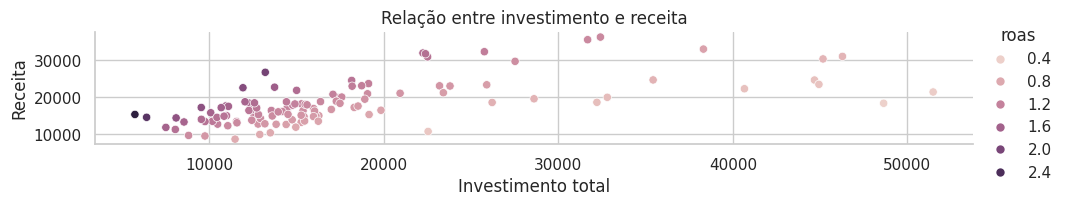

In [19]:
df['roas'] = df['Receita Líquida'] / df['investimento_total']

f = sns.relplot(x=df['investimento_total'], y=df['Receita Líquida'], data=df, hue='roas', height=2, aspect=5)
_ = f.set(title='Relação entre investimento e receita', xlabel='Investimento total', ylabel='Receita')

O gráfico de ``relplot`` acima mostra que gastar mais nem sempre gera retorno proporcional: os pontos com ROAS mais alto (tons mais claros) aparecem em diferentes faixas de investimento, sem uma tendência clara de que mais investimento implica mais eficiência. Isso levanta a pergunta: em quais canais o aumento de investimento está de fato se traduzindo em mais receita?
O gráfico de espalhamento abaixo desdobra essa visão por canal, permitindo avaliar o comportamento individual de cada um.

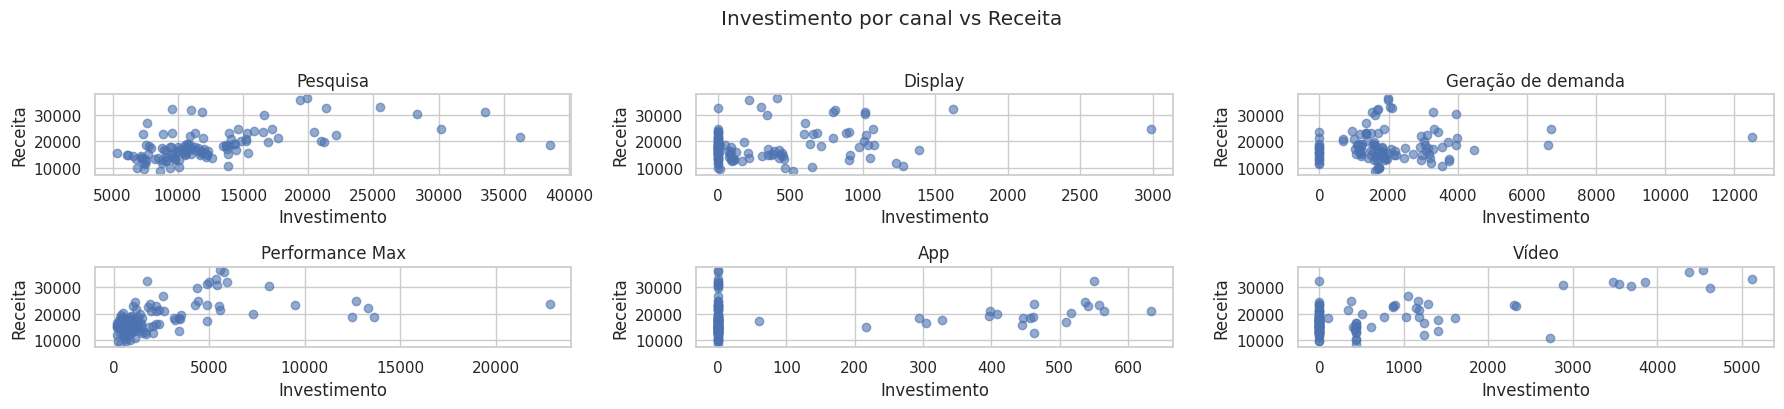

In [21]:
# Espalhamento por canal
canais = ['Pesquisa', 'Display', 'Geração de demanda', 'Performance Max', 'App', 'Vídeo']

fig, axes = plt.subplots(2, 3, figsize=(18, 4))
axes = axes.flatten()

for i, canal in enumerate(canais):
    axes[i].scatter(df[canal], df['Receita Líquida'], alpha=0.6)
    axes[i].set_title(canal)
    axes[i].set_xlabel('Investimento')
    axes[i].set_ylabel('Receita')

plt.suptitle('Investimento por canal vs Receita', y=1.02)
plt.tight_layout()
plt.show()

Logo abaixo, vamos printar os dados da matriz de correlação para ver esses dados de forma numérica.

### Matriz de correlação

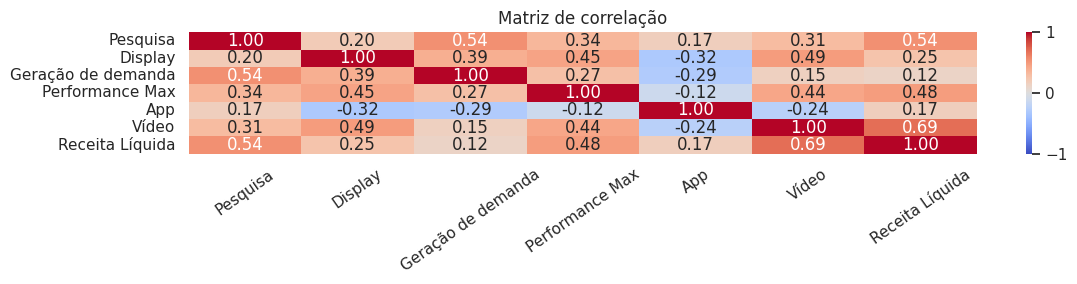

In [20]:
# Gráfico: Matriz de correlação
corr = df[ ['Pesquisa', 'Display', 'Geração de demanda', 'Performance Max', 'App', 'Vídeo', 'Receita Líquida'] ].corr()
fig, ax = plt.subplots(figsize=(12, 3))  # cria oquadro e o  eixo

sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1) #annot exibe os numeros dentro das celulas; vim e max evitam a normalização nas cores a partir dos valores
ax.set_title('Matriz de correlação')
ax.tick_params(axis = 'x', rotation = 35)

plt.tight_layout()
plt.show()

**Canais com relação positiva clara**



*   Pesquisa: melhor padrão de todos: conforme o investimento sobe, a receita tende a subir junto. Relação mais consistente visualmente, confirmando o 0.54 da matriz.
*   Vídeo: também mostra tendência positiva, especialmente nos investimentos mais altos (750+) que puxam receitas acima de 10.000. **Confirma o 0.69 da matriz de correlação**.






**Canais problemáticos**

*   App: a grande maioria dos pontos está empilhada em investimento ~0, ou seja, quase nunca é investido nesse canal. Os poucos dias com investimento não mostram padrão claro com receita.
*   Display: massa de pontos concentrada próxima de zero, com alguns outliers espalhados. Sem tendência clara.
*   Geração de demanda: parecido com Display: investimentos muito baixos na maioria dos dias, sem relação evidente com receita.



**Performance Max: o mais interessante**

O padrão é inverso ao esperado: os dias com maior receita (10.000+) aparecem com investimento baixo (próximo de zero), enquanto dias com investimento alto (6.000–7.000) têm receita mediana. Isso pode indicar que esse canal está sendo ativado nos dias errados, ou que há um problema de atribuição.


>Reforçando a hipótese anterior: Pesquisa e Vídeo são os canais com evidência mais clara de retorno. Os demais merecem revisão de estratégia, especialmente Performance Max, cujo comportamento é o mais suspeito.



### Questionamento complementar

A título de curiosidade, vamos avaliar esses dados em 2 períodos:

*   um com os dados de todo o período, exceto os últimos 30 dias, que corresponde ao período em que fizemos mudança de estratégia de campanhas;
*   o outro considerando apenas os dados dos últimos 30 dias, período com a nova estratégia de campanhas.

O objetivo é tentar descobrir se a estratégia de campanha, para cada tipo, estava alinhada com o resultado, ou seja, se estava cumprindo seu papel. Se, em um dos períodos, a campanha de Pesquisa, por exemplo, estava com estratégia de Maximizar conversões, não era mesmo esperado que ela crescesse em Receita à medida que se ia crescendo em Investimento. Mas caso a campanha estivesse com estratégia de Maximizar valor da conversão (ROAS), então o esperado seria ver a Receita média mais alta nos dias com mais investimento, ROAS consistente e positivo nos canais principais e espalhamento (scatter) com tendência positiva clara.




### Período do ano antes dos últimos 30 dias

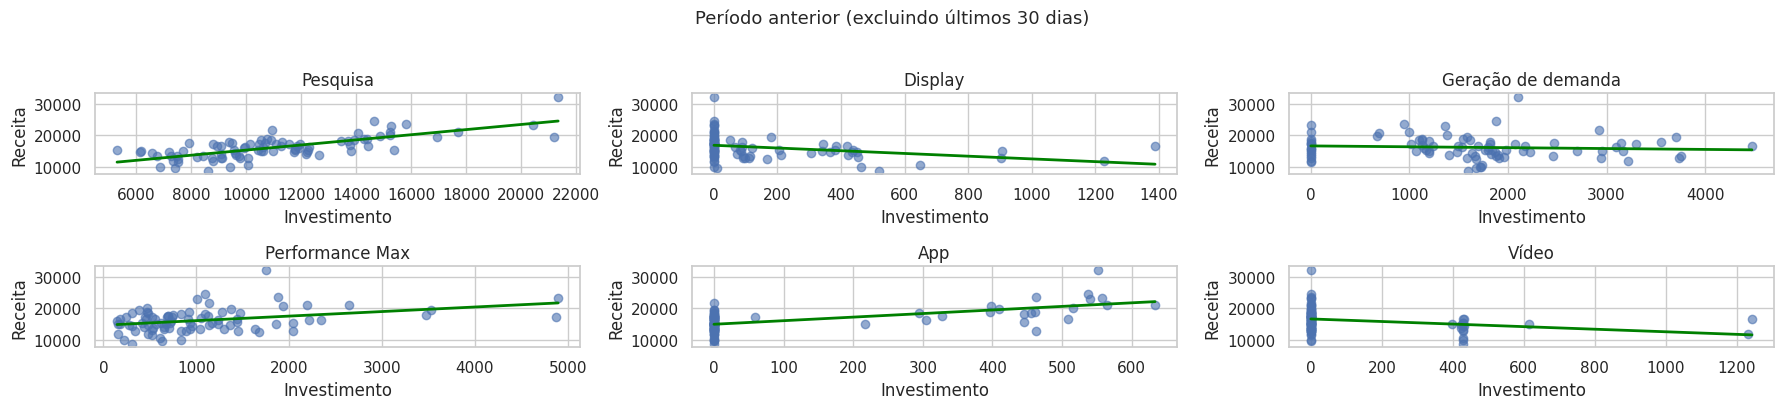

In [22]:
df_anterior = df.sort_values('Data').iloc[:-30].reset_index(drop=True)

canais = ['Pesquisa', 'Display', 'Geração de demanda', 'Performance Max', 'App', 'Vídeo']

fig, axes = plt.subplots(2, 3, figsize=(18, 4))
axes = axes.flatten()

for i, canal in enumerate(canais):
    axes[i].scatter(df_anterior[canal], df_anterior['Receita Líquida'], alpha=0.6)

    # linha de tendência só se houver variação suficiente no canal
    if df_anterior[canal].std() > 0:
        z = np.polyfit(df_anterior[canal], df_anterior['Receita Líquida'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_anterior[canal].min(), df_anterior[canal].max(), 100)
        axes[i].plot(x_line, p(x_line), color='green', linewidth=2)

    axes[i].set_title(canal)
    axes[i].set_xlabel('Investimento')
    axes[i].set_ylabel('Receita')

plt.suptitle('Período anterior (excluindo últimos 30 dias)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Para esses resultados, vemos que:



*   Pesquisa: tendência positiva clara, a mais consistente do quadro. Confirma que no período anterior Pesquisa estava funcionando bem.
*   Performance Max e App: tendência levemente positiva, mas pontos muito dispersos. Relação com receita existe mas é fraca.
*   Display: tendência negativa, sem contribuição real.
*   Geração de demanda: praticamente plano, sem relação com receita.
*   Vídeo: a linha está levemente negativa, mas isso é puxado pelos poucos pontos com investimento alto que têm receita baixa. A massa de pontos está empilhada em zero, ou seja, Vídeo quase não era usado no período anterior.








### Período dos últimos 30 dias

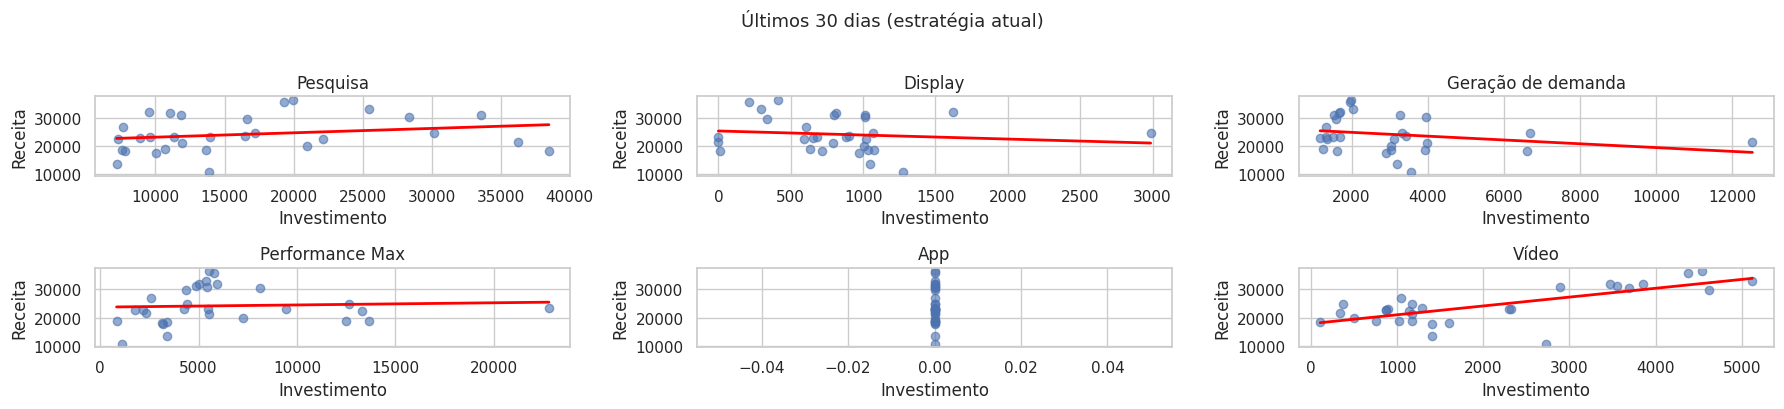

In [23]:
df_atual = df.sort_values('Data').iloc[-30:].reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 4))
axes = axes.flatten()

for i, canal in enumerate(canais):
    axes[i].scatter(df_atual[canal], df_atual['Receita Líquida'], alpha=0.6)

    if df_atual[canal].std() > 0:
        z = np.polyfit(df_atual[canal], df_atual['Receita Líquida'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_atual[canal].min(), df_atual[canal].max(), 100)
        axes[i].plot(x_line, p(x_line), color='red', linewidth=2)

    axes[i].set_title(canal)
    axes[i].set_xlabel('Investimento')
    axes[i].set_ylabel('Receita')

plt.suptitle('Últimos 30 dias (estratégia atual)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Para esses resultados, vemos que:



*   Pesquisa: nos dois períodos tem tendência positiva. Nos últimos 30 dias a dispersão aumentou bastante (pontos mais espalhados), o que pode indicar que o canal ficou menos previsível com a nova estratégia.

*   Vídeo: a mudança mais clara entre os dois períodos. No período anterior quase não era usado (pontos empilhados em zero). Nos últimos 30 dias passou a ter investimento real e mostra tendência positiva consistente; é o canal com a linha mais limpa do quadro atual.

*   Performance Max: perdeu a tendência positiva que tinha antes. Nos últimos 30 dias a linha está praticamente plana ou levemente negativa, com pontos muito dispersos.

*   Display e DGen: continuam com tendência negativa nos dois períodos, sem mudança relevante.
*   App: o eixo X está mostrando valores entre -0.04 e 0.5, o que indica que essa coluna provavelmente tem valores muito próximos de zero (o que é o caso dos dados atuais) ou com problema de tipo.




# Análise complementar: Checando a influência das campanhas de Vídeo na Receita

Por conta do resultado na matriz de correlação ser o mais alto ao relacionar Vídeo e Receita, e por conta de campanhas de Vídeo não terem objetivo direto de conversão (compra), vou analisar alguns caminhos para mensurar o real impacto da ativação desse canal na receita.

###Caminho 1: linha de tendência

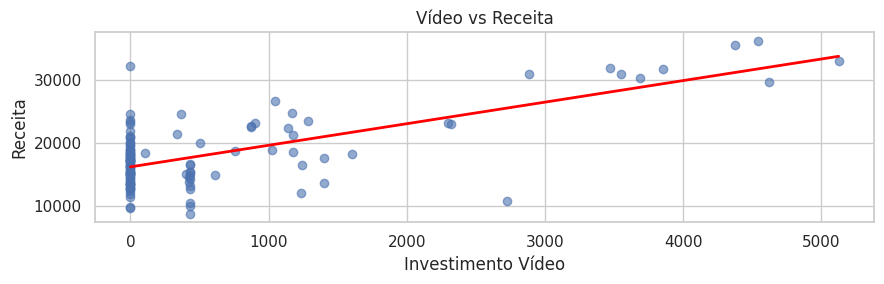

In [24]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.scatter(df['Vídeo'], df['Receita Líquida'], alpha=0.6)

z = np.polyfit(df['Vídeo'], df['Receita Líquida'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Vídeo'].min(), df['Vídeo'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2)

ax.set_title('Vídeo vs Receita')
ax.set_xlabel('Investimento Vídeo')
ax.set_ylabel('Receita')
plt.tight_layout()
plt.show()

A reta vermelha tem inclinação positiva clara, diferente de Display e DGen, aqui a tendência é visível.

Porém há um detalhe importante: a grande massa de pontos está empilhada próxima de zero (Vídeo inativo), e a reta é puxada pelos poucos dias com investimento alto. Isso significa que a relação **existe, mas é baseada em poucos dias de investimento real em Vídeo**.

### Caminho 2: Receita média com Vídeo ativo vs inativo

Aqui o objetivo é compara o quanto entrou de receita média nos dias em que o canal Vídeo estava ativo e inativo.

In [25]:
df['video_ativo'] = (df['Vídeo'] > 0).astype(int)
print(df.groupby('video_ativo')['Receita Líquida'].mean().rename({0: 'Vídeo inativo', 1: 'Vídeo ativo'}))

video_ativo
Vídeo inativo    16792.035072
Vídeo ativo      20430.150028
Name: Receita Líquida, dtype: float64


Os dados mostram receita média de 20.430 reais nos dias com Vídeo ativo contra 16.792 reais nos dias com Vídeo inativo, uma diferença de cerca de 3.638 (22% a mais). É a maior diferença absoluta encontrada entre todos os canais analisados até aqui.

###Caminho 3: verificando a dependência do investimento total

A ideia aqui é verificar se, nos dias em que o canal de Vídeo está ativo, o
investimento total também é alto.

Queremos entender se a receita maior nos dias de Vídeo ativo é por causa do Vídeo, ou porque nesses dias simplesmente gastou-se mais em tudo?

In [26]:
print(df.groupby('video_ativo')['investimento_total'].mean().rename({0: 'Vídeo inativo', 1: 'Vídeo ativo'}))

video_ativo
Vídeo inativo    14248.461739
Vídeo ativo      23211.232979
Name: investimento_total, dtype: float64


Uma armadilha: nos dias com Vídeo ativo, o investimento total médio é de 23.211 reais, contra 14.248 reais nos dias sem Vídeo, uma diferença de 63% a mais. Isso significa que a receita maior nesses dias pode ser explicada simplesmente pelo budget geral mais alto, não necessariamente pelo Vídeo em si. Para verificar isso, vamos para o passo abaixo.

###Caminho 4: isolando dentro de uma faixa de investimento similar

Vou pegar só os dias em que o investimento total foi parecido (entre 5.000 e 8.000), e dentro desse grupo comparo os dias com e sem Vídeo ativo.

Assim estaremos comparando dias com investimento similar, e a única diferença relevante passa a ser se o Vídeo estava ou não rodando. Se a receita ainda for maior com Vídeo ativo dentro desse grupo controlado, aí sim o argumento fica mais sólido, porque o investimento total não explica mais a diferença.

In [27]:
# Comparar dentro de uma faixa de investimento similar
df_controlado_video = df[(df['investimento_total'] >= 5000) & (df['investimento_total'] <= 8000)]

print(f"Registros: {len(df_controlado_video)}")
print(df_controlado_video.groupby('video_ativo')['Receita Líquida'].mean().rename({0: 'Vídeo inativo', 1: 'Vídeo ativo'}))

Registros: 3
video_ativo
Vídeo inativo    13967.6881
Name: Receita Líquida, dtype: float64


Dentro da faixa de investimento total entre 5.000 e 8.000 reais, há apenas 3 registros, e todos pertencem ao grupo "Vídeo inativo" (receita média de 13.968). Não há dias com Vídeo ativo dentro dessa faixa de controle, o que inviabiliza a comparação direta.


Esse resultado não invalida a hipótese de contribuição do Vídeo, ele apenas mostra que, nos dados disponíveis, os dias com Vídeo ativo tendem a ocorrer em faixas de investimento total mais altas, tornando difícil isolar o efeito do canal de forma controlada com esse volume de dados. A análise de regressão, feita adiante, é uma forma mais robusta de lidar com essa questão.


# Análise complementar: Checando a contribuição de Display e DGen nas campanhas de Pesquisa

Vamos avaliar se as campanhas de Display e DGen podem ter alguma influência sobre as campanhas de pesquisa. Levantei essa suspeita porque a campanha de Display roda apenas em sites mais premium e DGen tem objetivo de Tráfego, sendo, teoricamente, direcionada a um público mais qualificado que  das campanhas de Vídeo.

###Caminho 1: Dados da Matriz de correlação

Através da matriz de correlação, vemos que Display tem contribuição fraca (0.20) e Geração de demanda tem contribuição moderada (0.54).

Vamos ver com um pouco mais de precisão na tabela abaixo.

###Caminho 2: checando se dias com Display/DGen ativo têm mais receita via Pesquisa.

Se a receita média for maior nos dias com Display/DGen ativos, há indício de contribuição.

In [28]:
# Criar flag: canal estava ativo naquele dia?
df['display_ativo'] = (df['Display'] > 0).astype(int)
df['gd_ativo'] = (df['Geração de demanda'] > 0).astype(int)

# Comparar receita média nos dias com e sem cada canal ativo
for flag, nome in [('display_ativo', 'Display'), ('gd_ativo', 'Geração de demanda')]:
    print(f"\n--- {nome} ---")
    print(df.groupby(flag)['Receita Líquida'].mean().rename({0: 'Canal inativo', 1: 'Canal ativo'}))


--- Display ---
display_ativo
Canal inativo    17772.450355
Canal ativo      18653.423126
Name: Receita Líquida, dtype: float64

--- Geração de demanda ---
gd_ativo
Canal inativo    16178.900131
Canal ativo      18600.050692
Name: Receita Líquida, dtype: float64


Display: receita média de 18.653 quando o canal está ativo contra 17.772 reais quando inativo, diferença de cerca de 881 (5%). Um sinal fraco.


Geração de demanda: receita média de 18.600 quando ativo contra 16.179 reais quando inativo, diferença de cerca de 2.421 (15%). Um sinal mais expressivo, sugerindo que DGen pode ter alguma influência indireta na receita.


Geração de demanda mostra o impacto mais relevante entre os dois, mas antes de concluir qualquer coisa, precisamos checar se essa diferença não é simplesmente reflexo de dias com mais investimento total.

###Caminho 3: gráfico de espalhamento de Pesquisa vs Receita, colorido por Display/DGen ativo

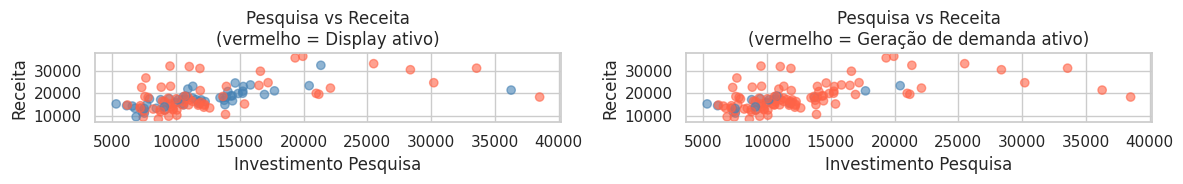

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 2))

for ax, flag, nome in zip(axes, ['display_ativo', 'gd_ativo'], ['Display', 'Geração de demanda']):
    cores = df[flag].map({0: 'steelblue', 1: 'tomato'})
    ax.scatter(df['Pesquisa'], df['Receita Líquida'], c=cores, alpha=0.6)
    ax.set_title(f'Pesquisa vs Receita\n(vermelho = {nome} ativo)')
    ax.set_xlabel('Investimento Pesquisa')
    ax.set_ylabel('Receita')

plt.tight_layout()
plt.show()

Display (esquerdo): pontos vermelhos e azuis estão bem misturados em todo o gráfico, não há separação clara. Display ativo não parece mudar o padrão de receita via Pesquisa.


Geração de demanda (direito): os pontos vermelhos aparecem com mais frequência nas receitas mais altas (acima de 8.000–10.000), enquanto os azuis ficam mais concentrados na faixa baixa. A separação é mais visível aqui.

Geração de demanda **parece ter um papel assistido real**, especialmente nos dias de alta receita. Isso faz sentido como canal de topo de funil, não gera receita diretamente, mas pode estar aquecendo a audiência que converte via Pesquisa.

### Caminho 4: nos dias com DGen + Pesquisa ativos juntos, qual é a receita média vs dias com só Pesquisa?

In [30]:
df['gd_e_pesquisa'] = ((df['gd_ativo'] == 1) & (df['Pesquisa'] > 0)).astype(int)
print(df.groupby('gd_e_pesquisa')['Receita Líquida'].mean().rename({0: 'Só Pesquisa', 1: 'GD + Pesquisa'}))

gd_e_pesquisa
Só Pesquisa      16178.900131
GD + Pesquisa    18600.050692
Name: Receita Líquida, dtype: float64


Uma diferença de cerca de 2.421 (15% a mais) nos dias em que os dois canais rodam juntos. Isso reforça a hipótese de efeito assistido de DGen sobre Pesquisa: nos dias com ambos ativos, a receita é consistentemente maior.
Porém, o alerta se confirma ao checar o investimento total médio por grupo:


*   Só Pesquisa: 11.577

*   GD + Pesquisa: 18.888

Os dias com DGen + Pesquisa têm 63% mais investimento total. A receita maior nesses dias provavelmente é consequência do budget geral mais alto, não da combinação dos canais em si.

In [31]:
print("\nInvestimento total médio por grupo:")
print(df.groupby('gd_e_pesquisa')['investimento_total'].mean().rename({0: 'Só Pesquisa', 1: 'GD + Pesquisa'}))


Investimento total médio por grupo:
gd_e_pesquisa
Só Pesquisa      11577.1650
GD + Pesquisa    18888.3717
Name: investimento_total, dtype: float64


In [32]:
# Filtrar dias com investimento total parecido (ex: entre 4000 e 6000)
df_controlado = df[(df['investimento_total'] >= 4000) & (df['investimento_total'] <= 6000)]

print(f"Registros no grupo controlado: {len(df_controlado)}")
print(df_controlado.groupby('gd_e_pesquisa')['Receita Líquida'].mean().rename({0: 'Só Pesquisa', 1: 'GD + Pesquisa'}))

Registros no grupo controlado: 1
gd_e_pesquisa
Só Pesquisa    15393.9462
Name: Receita Líquida, dtype: float64


Dentro da faixa de investimento total entre 4.000 e 6.000 reais, há apenas 1 registro, pertencente ao grupo "Só Pesquisa" (receita de 15.394). Não há dias com DGen ativo dentro dessa faixa, impossibilitando a comparação controlada.

O resultado reforça a mesma limitação encontrada na análise do Vídeo: os dias em que múltiplos canais estão ativos tendem a ser dias de maior investimento total, o que torna difícil separar o efeito do canal do efeito do budget via segmentação simples.

Isso não significa que DGen não tem efeito, significa que os dados disponíveis não permitem confirmar ou refutar isso com esse método. A regressão múltipla, adiante, tenta fazer esse isolamento de forma mais rigorosa.

# Modelo de regressão linear

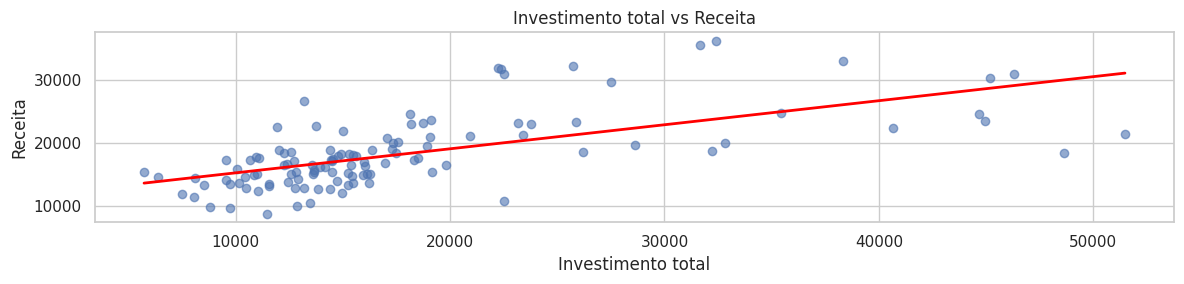

In [33]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(df['investimento_total'], df['Receita Líquida'], alpha=0.6)

z = np.polyfit(df['investimento_total'], df['Receita Líquida'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['investimento_total'].min(), df['investimento_total'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2)

ax.set_title('Investimento total vs Receita')
ax.set_xlabel('Investimento total')
ax.set_ylabel('Receita')
plt.tight_layout()
plt.show()

Com o gráfico acima, podemos ver que é possível notar que os pontos se acumulam em torno na linha vermelha, sugerindo que podemos modelar os resultados aproximadamente por uma regressão linear.

## Preparação para o modelo

Separando variáveis dependentes e independentes.

Divisão de dados de teste e treino.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
# investimento é a variável independente
X = df[ ['Pesquisa', 'Display', 'Geração de demanda', 'Performance Max', 'App', 'Vídeo'] ]
# receita é a variavel dependente
Y = df['Receita Líquida']

In [43]:
# vou dividir 20% dos dias para a base de teste e os outros 80% ddos dias ficam para treino
#X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size = 0.2, random_state = 42)
# a divisão acima era ruim pq, com o random, dividia de forma randomica.
# do modelo abaixo vo dividir cronologicamente

# Corte cronológico: 80% dos primeiros dias ficam para treino, 20% últimos dias ficam para teste
df = df.sort_values('Data').reset_index(drop=True)

corte = int(len(df) * 0.80)

X_treino = X.iloc[:corte]
X_teste  = X.iloc[corte:]
Y_treino = Y.iloc[:corte]
Y_teste  = Y.iloc[corte:]

print(f"Treino: {len(X_treino)} dias")
print(f"Teste:  {len(X_teste)} dias")
print(f"Período treino: {df['Data'].iloc[0]} até {df['Data'].iloc[corte-1]}")
print(f"Período teste:  {df['Data'].iloc[corte]} até {df['Data'].iloc[-1]}")

Treino: 92 dias
Teste:  24 dias
Período treino: 2026-01-01 00:00:00 até 2026-04-02 00:00:00
Período teste:  2026-04-03 00:00:00 até 2026-04-26 00:00:00


Printando só para ver como ficou.

In [44]:
print("Shape X_treino: ", X_treino.shape)
print("Shape X_teste: ", X_teste.shape)
print("Shape Y_treino: ", Y_treino.shape)
print("Shape Y_teste: ", Y_teste.shape)

print("\nSemanas no treino: ", X_treino.shape[0])
print("Semanas no teste: ", X_teste.shape[0])

Shape X_treino:  (92, 6)
Shape X_teste:  (24, 6)
Shape Y_treino:  (92,)
Shape Y_teste:  (24,)

Semanas no treino:  92
Semanas no teste:  24


## Treinamento do modelo de regressão linear

In [45]:
modelo = LinearRegression()
modelo.fit(X_treino, Y_treino)

LinearRegression()

In [46]:
print("Intercepto (constante que indica quanto receberíamos de receita se desligássemos todos os canais): ", round(modelo.intercept_, 2) )
print("\nCoeficientes por plataforma: ")

df_coeficientes = pd.DataFrame( {'plataforma': X.columns.tolist(), 'coeficiente': modelo.coef_.round(4)} )
print(df_coeficientes)

Intercepto (constante que indica quanto receberíamos de receita se desligássemos todos os canais):  10882.03

Coeficientes por plataforma: 
           plataforma  coeficiente
0            Pesquisa       0.3858
1             Display      -0.6051
2  Geração de demanda      -0.3137
3     Performance Max       0.7174
4                 App       6.3562
5               Vídeo       0.6079


Os coeficientes positivos fazem sentido econômico:

*   App: 6.36, o mais alto, mas deve ser interpretado com cautela, pois o canal fica inativo na maioria dos dias, o que torna esse coeficiente instável por falta de observações suficientes.
*   Performance Max: 0.72 e Pesquisa: 0.39, contribuição positiva moderada.
*   Vídeo: 0.61, contribuição positiva consistente com o que vimos na análise exploratória.


Os coeficientes negativos são um sinal de alerta:

*   Display: -0.61 e Geração de demanda: -0.31. O modelo está indicando que investir nesses canais reduz receita, o que não faz sentido econômico e sugere distorção por multicolinearidade.


Os coeficientes negativos, somados ao intercepto elevado (10.882), sugerem que o modelo está com dificuldade de separar o efeito individual de cada canal quando eles sobem e descem juntos, o que é exatamente o que acontece quando há multicolinearidade.

Coeficientes negativos já levantam suspeitas sobre multicolinearidade.


Sobre os coeficientes
Os coeficientes positivos fazem sentido:



*   Vídeo: 2.67, o mais alto, confirmando tudo que vimos na análise exploratória.
*   App: 4.88, pode estar capturando algo real ou ser instável por poucos dados.
*   Performance Max: 0.31 e Pesquisa: 0.43, contribuição positiva moderada.


Os coeficientes negativos são um sinal de alerta:

*   Display: -1.48 e Geração de demanda: -0.48, o modelo está dizendo que investir nesses canais reduz receita, o que não faz sentido econômico.

Os coeficientes negativos sugerem multicolinearidade, quando canais sobem e descem juntos, **o modelo tem dificuldade de separar o efeito individual de cada um e distorce os coeficientes**, podendo até inverter o sinal.

## Validação do modelo: Métricas de validação da regressão linear (R^2, MAE, RMSE)

Calculando os parâmetros para ver se esse modelo de Regressão linear simples é confiável para tomadas de decisão, tais como:



*   Estimar a contribuição de cada canal **(nosso objetivo principal aqui)**;
*   Simular cenários de orçamento (se realocarmos budget para Vídeo, quanto de receita incremental podemos esperar?);
*   Monitorar ao longo do tempo: retreinar o modelo mensalmente conforme acumula dados da nova estratégia.
*   Alertas de performance: identificar quando um canal está performando abaixo do coeficiente esperado.


Caso os resultados sejam suspeitos, podemos concluir que esse modelo não é confiável para tomada de decisão e vamos buscar outros modelos.

In [47]:
Y_previsto = modelo.predict(X_teste)

# calculando métricas
r2 = r2_score(Y_teste, Y_previsto)
mae = mean_absolute_error(Y_teste, Y_previsto)
rmse = np.sqrt(mean_squared_error(Y_teste, Y_previsto))

print("Métricas de validação — dados de teste:")
print(f"  R²:   {round(r2, 4)}")
print(f"  MAE:  R$ {round(mae, 2)}")
print(f"  RMSE: R$ {round(rmse, 2)}")

# comparando previsto vs real
df_validacao = pd.DataFrame({
    'receita_real': Y_teste.values,
    'receita_prevista': Y_previsto.round(2),
    'erro_absoluto': abs(Y_teste.values - Y_previsto).round(2),
    'erro_pct': (abs(Y_teste.values - Y_previsto) / Y_teste.values * 100).round(1)
})

print("\nComparação previsto vs real (primeiras 10 semanas de teste):")
print(df_validacao.head(10))

Métricas de validação — dados de teste:
  R²:   -0.4237
  MAE:  R$ 6065.96
  RMSE: R$ 7205.34

Comparação previsto vs real (primeiras 10 semanas de teste):
   receita_real  receita_prevista  erro_absoluto  erro_pct
0    23085.5253          20787.04        2298.49      10.0
1    23136.2359          22114.59        1021.64       4.4
2    18640.4013          21619.72        2979.32      16.0
3    21269.9184          18436.90        2833.02      13.3
4    24728.1321          25628.91         900.78       3.6
5    22344.4905          28043.32        5698.83      25.5
6    20028.2838          22939.84        2911.55      14.5
7    18673.6665          24806.97        6133.30      32.8
8    13564.9221          15318.22        1753.30      12.9
9    17661.9942          16400.14        1261.85       7.1


O R² de -0.4237 confirma que o modelo está pior do que simplesmente prever a média da receita para todos os dias. Isso acontece por dois motivos combinados:

*   Multicolinearidade distorcendo os coeficientes: canais que sobem e descem juntos confundem o modelo, que não consegue isolar o efeito individual de cada um.
*   Divisão cronológica expôs a quebra de padrão: os últimos 20% dos dias (período de teste, de 03/04 a 26/04) têm um comportamento diferente dos primeiros 80% usados no treino, por conta da mudança de estratégia de campanhas. O modelo aprendeu um padrão que simplesmente deixou de existir no período que precisava prever.


O MAE de 6.066 reais e o RMSE de 7.205 reais reforçam o ponto: o erro médio absoluto representa cerca de 33% da receita média, o que é alto demais para qualquer uso prático. A tabela de comparação entre previsto e real mostra erros que chegam a 32% em alguns dias, **confirmando que esse modelo não é confiável para tomada de decisão**.



#### VIF (Variance Inflation Factor) como recurso de diagnóstico


Num caso como esse, precisamos calcular o Variance Inflation Factor (VIF) para decidir quais canais remover ou combinar antes de retreinar, para que o modelo tenha uma chance real de funcionar.

O VIF é o fator de inflação da variância. Ele mede o quanto a variância do coeficiente de um canal é inflada por causa da correlação com os outros canais.

Na prática, a pergunta que ele responde é: "Consigo prever o investimento do canal X a partir dos outros canais?"

Se a resposta for "sim", o modelo de regressão vai se confundir, porque quando Pesquisa e DGen sobem juntos, ele não sabe se a receita subiu por causa da Pesquisa ou do DGen.

Em resumo, portanto, o VIF **mede a colinearidade**.

Os valores do VIF podem ter as seguintes interpretações:



*   VIF = 1: Sem correlação com outros canais (perfeito).
*   1 <= VIF < 5: Correlação baixa (aceitável).
*   5 <= VIF < 10: Correlação moderada (atenção).
*   VIF >= 10: Correlação severa (vai confundir o modelo).




In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['canal'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

                canal       VIF
0            Pesquisa  7.380461
2  Geração de demanda  5.237143
1             Display  2.424519
3     Performance Max  2.176718
5               Vídeo  2.127082
4                 App  1.838189


*   Pesquisa: 7,38 (problemático).
*   DGen:5,24 (limítrofe).
*   Display: 2,42 (ok).
*   PMax: 2,18 (ok).
*   Vídeo: 2,13 (ok).
*   App: 1,84 (ok).

Os resultados do VIF não ajudaram muito, pois Pesquisa, que é o nosso principal canal de investimento, teve o pior valor de VIF, de modo que não é interessante pensar um um modelo que exclua os resultados dessa variável.

Pesquisa e DGen são os canais mais complicados e que mais podem confundir o modelo. Sei que isso está acontecendo principalmente por conta da mudança de estratégia nos últimos 30 dias, forçando a multicolinearidade (que é mais uma consequência, em vez de uma causa).

Diante desse cenário (multicolinearidade confirmada pelo VIF, mas impossibilidade de remover Pesquisa do modelo) a alternativa natural é buscar um método de regressão que tolere a correlação entre variáveis sem precisar excluir nenhuma delas. É aqui que entra a **Regressão de Ridge**.

### Ridge Regression



Abaixo rodamos o modelo Ridge com os dados de todo o período. Antes de treinar, as variáveis precisam ser padronizadas (média zero, desvio padrão 1) via ``StandardScaler``, porque o Ridge penaliza coeficientes grandes, e se os canais estiverem em escalas diferentes, o modelo vai penalizar mais quem tem valores numericamente maiores, o que distorceria os resultados.

O parâmetro alpha controla a intensidade da penalização:


*   Alpha pequeno (0.1): penalização quase nula, comportamento muito próximo da regressão linear simples.

*   Alpha grande (100): penalização forte, coeficientes empurrados para perto de zero, o que reduz o impacto da multicolinearidade mas pode subestimar contribuições reais.

Testamos quatro valores para identificar se algum deles melhora o R^2 no período de teste antes de decidir o caminho seguinte.




In [49]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Ridge precisa que as variáveis estejam na mesma escala
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled  = scaler.transform(X_teste)

# alpha é a força da penalização — vamos testar alguns valores
for alpha in [0.1, 1, 10, 100]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_treino_scaled, Y_treino)
    Y_prev = ridge.predict(X_teste_scaled)
    r2 = r2_score(Y_teste, Y_prev)
    print(f"Alpha {alpha:6} → R²: {round(r2, 4)}")

Alpha    0.1 → R²: -0.4239
Alpha      1 → R²: -0.426
Alpha     10 → R²: -0.4495
Alpha    100 → R²: -0.5434


Note que conforme o alpha aumenta, o R^2 só piora.

Isso acontece porque a penalização está encolhendo coeficientes que, no período de teste, seriam úteis; reforçando que o problema principal não é a multicolinearidade em si, mas a quebra de padrão entre treino e teste provocada pela mudança de estratégia.

O Ridge é eficaz quando os dados têm estrutura consistente ao longo do tempo; aqui, o padrão aprendido no treino simplesmente não se replica no período de teste.



# Outras tentativas: Ridge regression em período menor e Regressão linear em período menor

## Modelo 1: Ridge (regressão normal) com todos os dados excluindo os últimos 30 dias do teste (para entender o que funcionava na estratégia anterior)

In [50]:
# Separar os dados excluindo os últimos 30 dias
df_anterior = df.sort_values('Data').iloc[:-30].reset_index(drop=True)

X_anterior = df_anterior[['Pesquisa', 'Display', 'Geração de demanda', 'Performance Max', 'App', 'Vídeo']]
Y_anterior = df_anterior['Receita Líquida']

# Divisão cronológica
corte = int(len(df_anterior) * 0.8)
X_treino = X_anterior.iloc[:corte]
X_teste  = X_anterior.iloc[corte:]
Y_treino = Y_anterior.iloc[:corte]
Y_teste  = Y_anterior.iloc[corte:]

# Treinar
modelo_anterior = LinearRegression()
modelo_anterior.fit(X_treino, Y_treino)

# Avaliar
Y_prev = modelo_anterior.predict(X_teste)
r2 = r2_score(Y_teste, Y_prev)
mae = mean_absolute_error(Y_teste, Y_prev)

print("=== MODELO 1: Estratégia anterior ===")
print(f"R²: {round(r2, 4)}")
print(f"MAE: R$ {round(mae, 2)}")
print(f"\nIntercepto: {round(modelo_anterior.intercept_, 2)}")
df_coef1 = pd.DataFrame({'canal': X_anterior.columns, 'coeficiente': modelo_anterior.coef_.round(4)})
print(df_coef1)

=== MODELO 1: Estratégia anterior ===
R²: -1.1989
MAE: R$ 2030.0

Intercepto: 8487.09
                canal  coeficiente
0            Pesquisa       0.6098
1             Display      -9.6938
2  Geração de demanda       0.4554
3     Performance Max       0.1733
4                 App       4.6732
5               Vídeo       6.1773


O R² negativo indica que o modelo ainda não generalizou bem para o período de teste, provavelmente pela multicolinearidade persistindo. Os coeficientes têm problemas sérios. Display: -9.69 é um valor absurdo, claramente distorcido.

**Esse modelo não é confiável para tomar decisões**.

##Modelo 2: Regressão simples só com os últimos 30 dias (para entender a estratégia atual, mesmo com a limitação de poucos dados)

In [51]:
# Apenas os últimos 30 dias
df_atual = df.sort_values('Data').iloc[-30:].reset_index(drop=True)

X_atual = df_atual[['Pesquisa', 'Display', 'Geração de demanda', 'Performance Max', 'App', 'Vídeo']]
Y_atual = df_atual['Receita Líquida']

# Com apenas 30 dias, vamos treinar em tudo e avaliar no próprio conjunto
# (sem divisão treino/teste por falta de dados suficientes)
modelo_atual = LinearRegression()
modelo_atual.fit(X_atual, Y_atual)

Y_prev_atual = modelo_atual.predict(X_atual)
r2_atual = r2_score(Y_atual, Y_prev_atual)
mae_atual = mean_absolute_error(Y_atual, Y_prev_atual)

print("=== MODELO 2: Estratégia atual (últimos 30 dias) ===")
print(f"R²: {round(r2_atual, 4)}")
print(f"MAE: R$ {round(mae_atual, 2)}")
print(f"\nIntercepto: {round(modelo_atual.intercept_, 2)}")
df_coef2 = pd.DataFrame({'canal': X_atual.columns, 'coeficiente': modelo_atual.coef_.round(4)})
print(df_coef2)

=== MODELO 2: Estratégia atual (últimos 30 dias) ===
R²: 0.5983
MAE: R$ 3152.33

Intercepto: 15865.79
                canal  coeficiente
0            Pesquisa       0.2505
1             Display      -0.2234
2  Geração de demanda      -0.6895
3     Performance Max       0.1583
4                 App       0.0000
5               Vídeo       2.6862


R^2 de 0.58 significa que o modelo explica 58% da variação da receita, razoável considerando que temos apenas 30 dias e 6 variáveis. Os coeficientes fazem mais sentido, apesar de alguns coeficientes terem valores negativos:



*   **Vídeo é consistente nos dois modelos**: aparece como o canal de maior retorno tanto na análise exploratória (0.69 de correlação) quanto nos dois modelos (2.67 e 2.69). Essa consistência é o resultado mais confiável de toda a análise.
*   Display e GD continuam problemáticos: os sinais negativos persistem, mas os valores são bem menores no Modelo 2, **o que sugere que parte do problema era a mudança de estratégia mesmo**.



Sendo assi, **o Modelo 2, apesar da limitação de poucos dados, é o mais relevante para decisões sobre a estratégia atual**. À medida que os dias forem passando e acumularmos mais dados da nova estratégia, vale retreinar esse modelo mensalmente; ele vai ficar mais robusto com o tempo.

# O que dá para fazer agora

O Modelo 2, apesar da limitação de poucos dados, é o mais aderente à estratégia atual e serve como ponto de partida para duas aplicações práticas demonstradas abaixo:

*   Estimativa de contribuição por canal e;
*   Simulação de cenários de orçamento.

À medida que mais dias forem acumulando com a nova estratégia de campanhas, vale retreinar o modelo mensalmente, pois ele tende a ficar mais estável e confiável com o tempo.

## Contribuição por canal

In [52]:
# Contribuição média de cada canal
investimento_medio = X_atual.mean()
contribuicao = investimento_medio * modelo_atual.coef_

df_contribuicao = pd.DataFrame({
    'canal': X_atual.columns,
    'investimento_medio': investimento_medio.round(2),
    'coeficiente_roas': modelo_atual.coef_.round(4),
    'contribuicao_media': contribuicao.round(2)
})


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print(df_contribuicao.to_string(index=False))

             canal  investimento_medio  coeficiente_roas  contribuicao_media
          Pesquisa            16630.38              0.25             4165.83
           Display              815.28             -0.22             -182.14
Geração de demanda             3010.07             -0.69            -2075.46
   Performance Max             6193.50              0.16              980.25
               App                0.00              0.00                0.00
             Vídeo             2020.16              2.69             5426.57


Com o modelo, os resultados de contribuição por canal ficam assim:


*   Vídeo se destaca com o maior ROAS implícito (2.69x) e a maior contribuição média diária estimada (5.427 reais), mesmo com investimento médio de apenas 2.020, o segundo menor entre os canais ativos. Cada real investido em Vídeo retorna aproximadamente 2.69 reais de receita incremental segundo o modelo.

*   Pesquisa recebe o maior volume de investimento (16.630 reais/dia), mas com ROAS implícito de apenas 0.25x, sua contribuição estimada é de R$ 4.166, menor do que Vídeo apesar de receber mais de 8x o budget. Isso não significa que Pesquisa seja ineficiente; pode refletir **tanto saturação de canal quanto limitação do modelo com poucos dados**.

*   Performance Max aparece com contribuição positiva de 980 reais e ROAS de 0.16x, modesto, mas sem sinal invertido.

*   Display (-182 reais) e Geração de demanda (-2.075 reais) apresentam contribuição negativa segundo o modelo. Como discutido ao longo da análise, esses sinais negativos provavelmente refletem multicolinearidade residual e **não devem ser interpretados como evidência de que esses canais prejudicam a receita**; apenas que o modelo não conseguiu isolá-los adequadamente com os dados disponíveis.

*   App apresenta investimento médio zero nos últimos 30 dias, portanto sem contribuição estimada no período atual.



/tmp/ipykernel_8430/1306140900.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


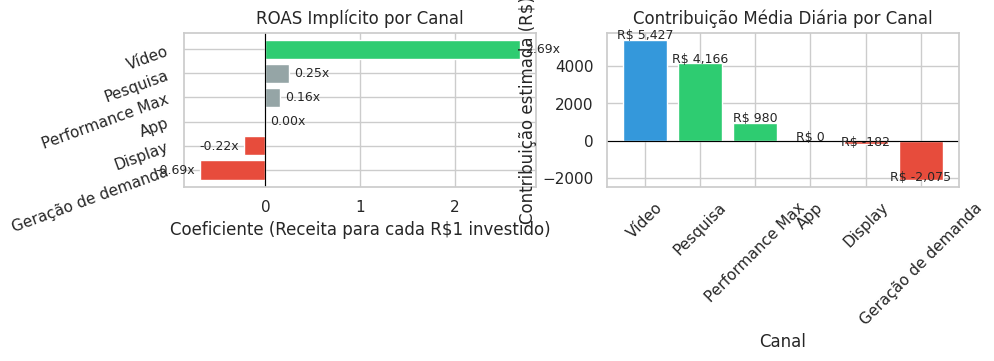

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2))

# --- Gráfico 1: ROAS implícito por canal ---
df_coef = df_contribuicao.sort_values('coeficiente_roas', ascending=True)
cores_roas = ['#e74c3c' if x < 0 else '#2ecc71' if x > 2 else '#95a5a6'
              for x in df_coef['coeficiente_roas']]

bars = axes[0].barh(df_coef['canal'], df_coef['coeficiente_roas'], color=cores_roas)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('ROAS Implícito por Canal')
axes[0].set_xlabel('Coeficiente (Receita para cada R$1 investido)')

for bar, val in zip(bars, df_coef['coeficiente_roas']):
    axes[0].text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}x', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# --- Gráfico 2: Contribuição média por canal ---
df_contrib = df_contribuicao.sort_values('contribuicao_media', ascending=False)
cores_contrib = ['#3498db' if x == df_contrib['contribuicao_media'].max()
                 else '#e74c3c' if x < 0
                 else '#2ecc71' if x > 100
                 else '#95a5a6' for x in df_contrib['contribuicao_media']]

bars2 = axes[1].bar(df_contrib['canal'], df_contrib['contribuicao_media'], color=cores_contrib)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Contribuição Média Diária por Canal')
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Contribuição estimada (R$)')

for bar, val in zip(bars2, df_contrib['contribuicao_media']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + (30 if val >= 0 else -60),
                 f'R$ {val:,.0f}', ha='center', fontsize=9)

axes[0].tick_params(axis='y', rotation=20)
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Simulando ajustes de orçamento

In [54]:
# Exemplo: o que acontece se eu dobrar o investimento em Vídeo?
cenario = X_atual.mean().copy()
cenario['Vídeo'] = cenario['Vídeo'] * 2

# as duas linhas abaixo geram warnings
#receita_simulada = modelo_atual.predict([cenario])[0]
#receita_atual = modelo_atual.predict([X_atual.mean()])[0]
receita_simulada = modelo_atual.predict(pd.DataFrame([cenario]))[0]
receita_atual = modelo_atual.predict(pd.DataFrame([X_atual.mean()]))[0]

print(f"Receita estimada atual diária: R$ {receita_atual:.2f}")
print(f"Receita diária estimada dobrando Vídeo: R$ {receita_simulada:.2f}")
print(f"Incremento estimado diário: R$ {receita_simulada - receita_atual:.2f}")

Receita estimada atual diária: R$ 24180.84
Receita diária estimada dobrando Vídeo: R$ 29607.41
Incremento estimado diário: R$ 5426.57


O exemplo acima simula o que aconteceria se o investimento diário em Vídeo fosse dobrado (de 2.020 para 4.040), mantendo os demais canais no investimento médio atual.

O modelo estima um incremento diário de 5.427, elevando a receita diária de 24.181 para 29.607.

É importante tratar esse número como uma estimativa indicativa, não uma previsão exata. O modelo foi treinado com apenas 30 dias de dados e não captura efeitos de saturação. Na prática, dobrar o investimento em qualquer canal **raramente dobra o retorno de forma linear**. O valor serve para **orientar** priorização de budget, não para projeções financeiras.



### Simulação de orçamento por canal

O simulador abaixo generaliza a lógica anterior para qualquer canal. Basta informar o canal desejado e o novo investimento diário que o modelo retorna a receita estimada, o incremento em relação ao cenário atual e as projeções semanal e mensal desse incremento.


Os investimentos médios diários atuais (base dos últimos 30 dias) são:

Pesquisa: 16.630
Display: 815
Geração de demanda: 3.010
Performance Max: 6.194
App: R$ 0
Vídeo: 2.020

Lembrando que para Display, DGen e App, os coeficientes do modelo têm limitações interpretativas discutidas ao longo da análise, de modo que simular aumentos nesses canais **vai gerar resultados numericamente válidos, mas que devem ser lidos com cautela**.

In [56]:
print("Canais disponíveis:")
for i, canal in enumerate(X_atual.columns):
    print(f"{i} - {canal} (investimento médio diário atual: R$ {X_atual[canal].mean():.2f})")

canal_escolhido = input("\nDigite o nome do canal que quer PREVER: ")
novo_investimento = float(input(f"Digite o novo investimento diário em {canal_escolhido} (R$): "))

# Montar cenário
cenario = pd.DataFrame([X_atual.mean()])
investimento_original = cenario[canal_escolhido].values[0]
cenario[canal_escolhido] = novo_investimento

# Calcular
receita_atual = modelo_atual.predict(pd.DataFrame([X_atual.mean()]))[0]
receita_simulada = modelo_atual.predict(cenario)[0]
incremento = receita_simulada - receita_atual
multiplo = novo_investimento / investimento_original if investimento_original > 0 else 0

print(f"\n=== Simulação: {canal_escolhido} ===")
print(f"Investimento diário atual:    R$ {investimento_original:.2f}")
print(f"Investimento diário simulado: R$ {novo_investimento:.2f} ({multiplo:.1f}x o atual)")
print(f"\nReceita média diária estimada atual:    R$ {receita_atual:.2f}")
print(f"Receita média diária estimada simulada: R$ {receita_simulada:.2f}")
print(f"Incremento diário estimado:             R$ {incremento:.2f}")
print(f"\nProjeção mensal do incremento (x30):    R$ {incremento * 30:.2f}")
print(f"Projeção semanal do incremento (x7):    R$ {incremento * 7:.2f}")

Canais disponíveis:
0 - Pesquisa (investimento médio diário atual: R$ 16630.38)
1 - Display (investimento médio diário atual: R$ 815.28)
2 - Geração de demanda (investimento médio diário atual: R$ 3010.07)
3 - Performance Max (investimento médio diário atual: R$ 6193.50)
4 - App (investimento médio diário atual: R$ 0.00)
5 - Vídeo (investimento médio diário atual: R$ 2020.16)

Digite o nome do canal que quer PREVER: Vídeo
Digite o novo investimento diário em Vídeo (R$): 600

=== Simulação: Vídeo ===
Investimento diário atual:    R$ 2020.16
Investimento diário simulado: R$ 600.00 (0.3x o atual)

Receita média diária estimada atual:    R$ 24180.84
Receita média diária estimada simulada: R$ 20365.99
Incremento diário estimado:             R$ -3814.85

Projeção mensal do incremento (x30):    R$ -114445.40
Projeção semanal do incremento (x7):    R$ -26703.93


# Limitações e Próximos passos


Esta análise tem valor como ponto de partida para mensuração de contribuição por canal, mas é importante ser transparente sobre suas limitações antes de usá-la para decisões de alocação de budget.

##Limitações do modelo atual


*   Volume de dados reduzido: o Modelo 2 foi treinado com apenas 30 dias de dados da estratégia atual. Com 6 variáveis independentes, o ideal estatístico seria ter no mínimo 60 observações. Os coeficientes tendem a ser instáveis e sensíveis a dias atípicos.

*   Ausência de divisão treino/teste no Modelo 2: **por falta de dados suficientes, o modelo foi avaliado no mesmo conjunto em que foi treinado**. Isso significa que o R^2 de 0.60 está otimista; o desempenho real em dados novos pode ser inferior.

*   Multicolinearidade residual: mesmo no período mais recente, alguns canais ainda se movem juntos, o que dificulta o isolamento do efeito individual. Os coeficientes negativos de Display e DGen são o sinal mais claro disso.

*   Linearidade assumida: o modelo assume que o retorno de cada canal é constante independentemente do volume investido. Na prática, canais costumam ter retornos decrescentes (gastar o dobro raramente gera o dobro de receita).

*   Sem controle de sazonalidade ou fatores externos: eventos promocionais, datas comemorativas e variações de demanda orgânica não estão capturados no modelo e podem inflar ou deflacionar os coeficientes de canais que coincidam com esses períodos.

##Próximos passos sugeridos

*   Acumular dados: com 60 ou mais dias da estratégia atual, retreinar o Modelo 2 e **incluir divisão cronológica treino/teste** para uma validação mais honesta.

*   Testar variáveis de controle: incluir indicadores como dia da semana, semana do mês ou flags de período promocional pode melhorar o ajuste do modelo e reduzir o ruído nos coeficientes.

*   Explorar modelos não-lineares: técnicas como Random Forest ou Gradient Boosting capturam relações mais complexas entre investimento e receita, e podem ser um próximo passo natural após consolidar a base de dados.

*   Marketing Mix Modeling (MMM): para uma mensuração mais robusta de contribuição por canal em contextos com multicolinearidade e efeitos de longo prazo (como Vídeo), o MMM é a abordagem mais adequada, incorporando efeitos de carryover, saturação e variáveis externas de forma estruturada.